# 07a — Khử trùng lặp

Notebook `01a` đếm được **29,4% kho văn bản là bản sao**: 1.654.055 tài liệu
nhưng chỉ 1.168.372 nội dung khác nhau. Notebook này biến con số đó thành điểm.

### Vấn đề nhìn từ danh sách ứng viên

Đo trên chính danh sách 100 ứng viên mà `bm25` đã tinh chỉnh trả về:

| Nhóm | 100 ứng viên còn lại bao nhiêu nội dung khác nhau |
| --- | --- |
| bitcoin | 49,0 |
| monero | 64,1 |
| history | 70,3 |
| cardano | 73,9 |

Trên `bitcoin`, một nửa danh sách là cùng một văn bản lặp lại dưới mã khác. Ở
bước xếp hạng lại, một nửa chi phí GPU dùng để chấm lại nội dung đã chấm rồi.

### Cái bẫy

Gộp bản sao lại nghe có vẻ hiển nhiên, nhưng nó làm mất đáp án. Lý do: danh
sách đáp án **không đánh dấu mọi bản sao**. Đo trên `quant`, có 5 nhóm bản sao
mà chỉ một phần các bản được đánh dấu đúng. Giữ lại nhầm bản là điểm 0 cho một
văn bản đúng từng chữ.

Notebook `01b` đã đo mức thiệt hại: khử trùng lặp ngây thơ mất 1–3% đáp án.

### Cách giải

Gộp lại để đếm, nhưng giữ đường quay về:

| Bước | Việc |
| --- | --- |
| Gộp | Mỗi nội dung giữ một mã, các mã còn lại ghi vào danh sách chờ |
| Trả lại | Khi xuất kết quả, cho phép tối đa `expand` mã của cùng một nội dung |

`expand = 1` tin vào việc gộp: mỗi chỗ trong top 10 là một nội dung khác nhau.
`expand = 3` phòng hờ: chịu tốn chỗ để phủ nhiều mã của cùng một nội dung.

Cái nào tốt hơn là câu hỏi về bộ dữ liệu này, nên mục 4 đo chứ không đoán.

### Đầu ra

| Kết quả | Dùng ở đâu |
| --- | --- |
| `results/dup_groups/<nhóm>.json` | Chặng `dedup` của mọi hệ thống sau này |
| Giá trị `expand` đã chốt | `07b`, `07c`, `07d` |
| Tỷ lệ gộp từng nhóm | Quyết định độ sâu cần lấy ở `07b` |

In [1]:
import sys
import json
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("..") / "src"))
import reteco as R
import pipeline as P

DATA = Path(r"D:\RETECO-project\reteco_data\track1_tempo")
SYSTEMS = Path("..") / "systems"
CACHE = Path("results")

for required in ("duplicate_groups", "collapse", "expand_groups"):
    assert hasattr(R, required), (
        f"src/reteco.py is missing {required}. Replace it with the current "
        f"version and restart the kernel.")

P.configure(DATA, CACHE)
domains = P.domains()
print(f"{len(domains)} domains")
print(f"dedup kinds available: {sorted(P._REGISTRY['dedup'])}")

13 domains
dedup kinds available: ['content_hash', 'none']


In [2]:
# --- Shared chart style -------------------------------------------------
# Same palette and helpers as every other notebook in the project, so a bar
# here means what a bar there means.
BLUE, ORANGE, TEAL, AMBER, PINK, VIOLET = (
    "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7")
SURFACE, INK, INK_SOFT, INK_MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, AXIS = "#e1e0d9", "#c3c2b7"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE, "axes.edgecolor": AXIS,
    "axes.labelcolor": INK_SOFT, "axes.labelsize": 9.5,
    "text.color": INK, "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "xtick.labelsize": 9.5, "ytick.labelsize": 9.5, "font.size": 10,
    "figure.dpi": 120, "axes.linewidth": 0.9,
})


def finish(ax, title, subtitle=None, xlabel=None, ylabel=None,
           grid_axis="y", note=None):
    if subtitle:
        ax.set_title(subtitle, loc="left", pad=8, fontsize=9.5, color=INK_MUTED)
        ax.annotate(title, xy=(0, 1), xycoords="axes fraction",
                    xytext=(0, 24), textcoords="offset points",
                    ha="left", va="bottom", fontsize=12.5,
                    fontweight="bold", color=INK, annotation_clip=False)
    else:
        ax.set_title(title, loc="left", pad=12, fontsize=12.5,
                     fontweight="bold", color=INK)
    ax.set_xlabel(xlabel or "")
    ax.set_ylabel(ylabel or "")
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.spines["left" if grid_axis == "x" else "bottom"].set_color(AXIS)
    if grid_axis == "x":
        ax.spines["bottom"].set_visible(False)
    elif grid_axis:
        ax.spines["left"].set_visible(False)
    if grid_axis:
        ax.grid(axis=grid_axis, color=GRID, linewidth=0.8)
        ax.set_axisbelow(True)
    ax.tick_params(length=0)
    if note:
        ax.text(0, -0.34, note, transform=ax.transAxes, ha="left", va="top",
                fontsize=8.5, color=INK_MUTED)
    return ax


def label_bars(ax, bars, values, fmt="{:,.0f}", horizontal=True, pad=0.015):
    span = max(values) if len(values) else 1
    for bar, value in zip(bars, values):
        if horizontal:
            ax.text(bar.get_width() + span * pad,
                    bar.get_y() + bar.get_height() / 2, fmt.format(value),
                    va="center", ha="left", fontsize=8.5, color=INK_SOFT)
        else:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + span * pad, fmt.format(value),
                    ha="center", va="bottom", fontsize=8.5, color=INK_SOFT)


def legend_below(ax, ncol=2, y=-0.30):
    ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, y),
              ncol=ncol, fontsize=9.5, handlelength=1.1, handleheight=1.1,
              columnspacing=1.8)

---

## 1. Dựng bảng nhóm bản sao

Một lượt quét toàn kho, băm nội dung từng tài liệu, ghi ra bảng
`{mã tài liệu: mã đại diện}` cho **những tài liệu có bản sao**. Tài liệu không
có bản sao thì vắng mặt trong bảng, và người đọc bảng hiểu vắng mặt nghĩa là
tự nó làm đại diện. Cách đó giữ bảng ở khoảng một phần ba kho thay vì cả kho.

Việc băm dùng nội dung đã chuẩn hoá khoảng trắng và hạ chữ thường, hơi rộng
hơn cách băm byte thô của `01a`. Rộng hơn là hướng an toàn cho một chặng có
nhiệm vụ dọn bản sao.

Chạy một lần, khoảng 8 phút. Các lần sau đọc lại từ file.

In [3]:
# --- One pass over the corpus, cached to results/dup_groups/ -------------
started = time.time()
group_summary = P.build_dup_groups()
print(f"\nTotal {time.time() - started:.0f}s")

total_docs = 0
print(f"\n{'domain':<12}{'docs':>10}{'in a group':>13}{'groups':>10}"
      f"{'share':>9}")
print("-" * 54)
rows = []
for domain in domains:
    n_docs = sum(1 for _ in open(DATA / domain / "documents.jsonl",
                                 encoding="utf-8"))
    s = group_summary[domain]
    share = s["in_groups"] / n_docs
    rows.append((domain, n_docs, s["in_groups"], s["groups"], share))
    total_docs += n_docs
    print(f"{domain:<12}{n_docs:>10,}{s['in_groups']:>13,}"
          f"{s['groups']:>10,}{share:>9.1%}")
print("-" * 54)

in_groups = sum(r[2] for r in rows)
group_count = sum(r[3] for r in rows)
distinct = total_docs - in_groups + group_count
print(f"{'all':<12}{total_docs:>10,}{in_groups:>13,}{group_count:>10,}"
      f"{in_groups / total_docs:>9.1%}")
print()
print(f"{total_docs:,} documents hold {distinct:,} distinct texts "
      f"({1 - distinct / total_docs:.1%} are copies).")


Total 0s

domain            docs   in a group    groups    share
------------------------------------------------------
bitcoin        153,291      107,920    31,327    70.4%
cardano         87,201       59,048    19,356    67.7%
economics       93,756       30,085    11,016    32.1%
genealogy      156,228       31,217    11,089    20.0%
history        356,493      201,410    45,162    56.5%
hsm            213,818       66,945    22,674    31.3%
iota            10,372          975       283     9.4%
law             43,288       11,621     4,434    26.8%
monero          85,093       44,324    13,181    52.1%
politics       183,394       68,397    20,201    37.3%
quant           28,785        5,896     2,151    20.5%
travel         177,677       31,671    12,758    17.8%
workplace       64,659       30,367     9,288    47.0%
------------------------------------------------------
all          1,654,055      689,876   202,920    41.7%

1,654,055 documents hold 1,167,099 distinct texts (29

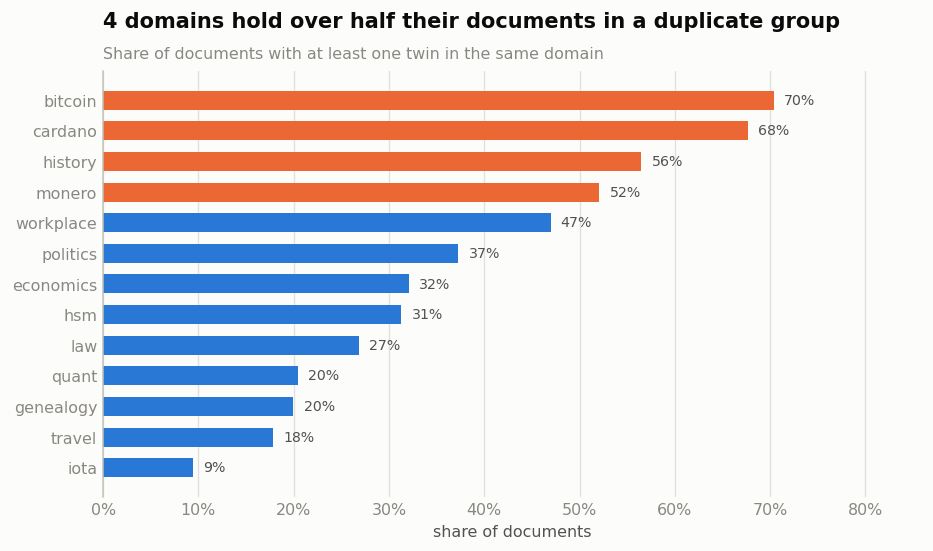

Heavily duplicated: bitcoin, cardano, history, monero


In [4]:
# --- Which domains carry the duplication ---------------------------------
order = sorted(rows, key=lambda r: -r[4])

fig, ax = plt.subplots(figsize=(8.8, 4.6))
bars = ax.barh([r[0] for r in order], [r[4] for r in order],
               color=[ORANGE if r[4] > 0.5 else BLUE for r in order],
               height=0.62)
ax.invert_yaxis()
ax.set_xlim(0, max(r[4] for r in order) * 1.22)
ax.xaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
label_bars(ax, bars, [r[4] for r in order], fmt="{:.0%}", horizontal=True)

heavy = [r[0] for r in order if r[4] > 0.5]
finish(ax, f"{len(heavy)} domains hold over half their documents in a duplicate group",
       subtitle="Share of documents with at least one twin in the same domain",
       xlabel="share of documents", grid_axis="x")
plt.show()

print("Heavily duplicated:", ", ".join(heavy) if heavy else "none")

---

## 2. Bản sao chiếm bao nhiêu chỗ trong danh sách ứng viên

Mục 1 đếm trên toàn kho. Nhưng điều thực sự tốn tiền là bản sao **lọt vào danh
sách ứng viên**, vì đó là phần sẽ đi qua GPU.

Mục này mở đúng danh sách 100 ứng viên mà hệ thống đã chốt ở `06b` trả về, rồi
đếm xem trong 100 chỗ đó có bao nhiêu nội dung khác nhau.

In [5]:
# --- How many of the 100 candidates are distinct texts -------------------
CHOSEN_SYSTEM = SYSTEMS / "01_bm25_tuned.json"
base_system = P.load_system(CHOSEN_SYSTEM)
base_digest = P.run(base_system, split="train")
P.score(base_digest)

ranked = P._load_run(base_digest)
gold_all = {d: R.load_qrels(DATA / d / "qrels_train.txt") for d in domains}

waste = []
print(f"{'domain':<12}{'queries':>9}{'candidates':>12}{'distinct':>10}"
      f"{'wasted':>9}{'gold with a twin':>18}")
print("-" * 70)
for domain in domains:
    canonical_of = P._load_groups(domain)
    per_query = ranked.get(domain, {})
    total = kept = 0
    twinned_gold = 0
    for qid, hits in per_query.items():
        ids = [doc for doc, _ in hits]
        distinct_ids, _ = R.collapse(ids, canonical_of)
        total += len(ids)
        kept += len(distinct_ids)
        in_list = set(ids)
        for doc in gold_all[domain].get(qid, ()):
            if doc in in_list:
                twin = canonical_of.get(doc, doc)
                if sum(1 for x in ids
                       if canonical_of.get(x, x) == twin) > 1:
                    twinned_gold += 1
    if not total:
        continue
    share = 1 - kept / total
    waste.append((domain, len(per_query), total / len(per_query),
                  kept / len(per_query), share, twinned_gold))
    print(f"{domain:<12}{len(per_query):>9}{total / len(per_query):>12.1f}"
          f"{kept / len(per_query):>10.1f}{share:>9.1%}{twinned_gold:>18}")
print("-" * 70)

overall = 1 - sum(w[3] * w[1] for w in waste) / sum(w[2] * w[1] for w in waste)
print(f"{'all':<12}{sum(w[1] for w in waste):>9}{'':>12}{'':>10}"
      f"{overall:>9.1%}{sum(w[5] for w in waste):>18}")
print()
print("The last column counts gold documents that share their text with")
print("another id in the same candidate list. Those are exactly the cases")
print("where collapsing can keep the wrong id and score zero on a correct")
print("text, which is what section 4 measures.")

  retrieve  f326339da67a  cached
domain        queries  candidates  distinct   wasted  gold with a twin
----------------------------------------------------------------------
bitcoin            70       100.0      49.0    51.0%                 7
cardano            36       100.0      73.7    26.3%                 1
economics          58       100.0      84.2    15.8%                 1
genealogy          80       100.0      79.7    20.4%                 0
history           561       100.0      70.2    29.8%                18
hsm               105       100.0      79.9    20.1%                 0
iota                7       100.0      92.1     7.9%                 1
law                24       100.0      91.9     8.1%                 2
monero             46       100.0      63.7    36.3%                 8
politics          105       100.0      81.3    18.7%                 0
quant              24       100.0      88.6    11.4%                 2
travel             70       100.0      80.0 

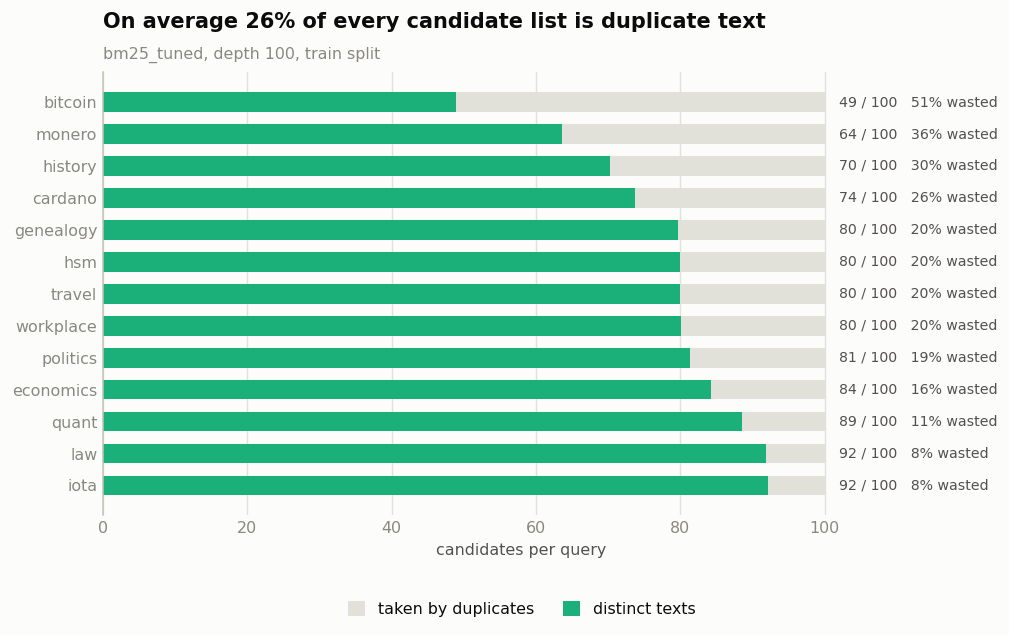

In [6]:
# --- The same picture as a chart -----------------------------------------
order = sorted(waste, key=lambda w: -w[4])

fig, ax = plt.subplots(figsize=(9.0, 4.8))
ys = np.arange(len(order))
ax.barh(ys, [w[2] for w in order], height=0.62, color=GRID,
        label="taken by duplicates")
bars = ax.barh(ys, [w[3] for w in order], height=0.62, color=TEAL,
               label="distinct texts")
ax.set_yticks(ys)
ax.set_yticklabels([w[0] for w in order])
ax.invert_yaxis()
ax.set_xlim(0, max(w[2] for w in order) * 1.16)
for y, w in zip(ys, order):
    ax.text(w[2] * 1.02, y, f"{w[3]:.0f} / {w[2]:.0f}   {w[4]:.0%} wasted",
            va="center", ha="left", fontsize=8.5, color=INK_SOFT)
legend_below(ax, ncol=2, y=-0.16)
finish(ax, f"On average {overall:.0%} of every candidate list is duplicate text",
       subtitle=f"{base_system['name']}, depth "
                f"{base_system['retrieve']['depth']}, train split",
       xlabel="candidates per query", grid_axis="x")
plt.show()

### Đọc biểu đồ

Phần xám là chỗ bị bản sao chiếm. Đó không phải chỗ trống — đó là những dòng
mà tầng một đã trả về, GPU sẽ chấm, và chúng mang đúng nội dung đã có ở dòng
trên.

Hệ quả cho `07b`: muốn có `n` nội dung khác nhau để xếp hạng lại thì phải lấy
về sâu hơn `n`. Mục 5 tính ra con số cụ thể.

---

## 3. Thử một câu truy vấn

Trước khi chạy cả 13 nhóm, mở một câu ra xem việc gộp làm gì với danh sách của
nó. Một ví dụ đọc được bằng mắt bắt lỗi nhanh hơn một bảng trung bình.

In [7]:
# --- One query, opened up -------------------------------------------------
example_domain = max(waste, key=lambda w: w[4])[0]
canonical_of = P._load_groups(example_domain)

# Pick the query whose list collapses the most: the clearest case.
candidates = []
for qid, hits in ranked[example_domain].items():
    ids = [doc for doc, _ in hits]
    kept_ids, _ = R.collapse(ids, canonical_of)
    candidates.append((len(ids) - len(kept_ids), qid))
shrink, example_qid = max(candidates)

ids = [doc for doc, _ in ranked[example_domain][example_qid]]
kept_ids, twins = R.collapse(ids, canonical_of)
gold = gold_all[example_domain].get(example_qid, set())

print(f"domain {example_domain}   query {example_qid}")
print(f"  candidates      {len(ids)}")
print(f"  distinct texts  {len(kept_ids)}")
print(f"  gold documents  {len(gold)}")
print()
print("First 12 candidates, with their group:")
print(f"{'rank':<6}{'document':<34}{'group':<34}{'note'}")
print("-" * 92)
for rank, doc in enumerate(ids[:12], start=1):
    canonical = canonical_of.get(doc, doc)
    note = []
    if doc in gold:
        note.append("GOLD")
    if canonical != doc:
        note.append("copy")
    if doc in twins:
        note.append(f"{len(twins[doc])} copies behind it")
    print(f"{rank:<6}{doc[-33:]:<34}{canonical[-33:]:<34}{', '.join(note)}")
print("-" * 92)

biggest = max(twins.items(), key=lambda kv: len(kv[1]), default=(None, []))
if biggest[0]:
    print(f"\nLargest group in this list: {biggest[0][-33:]} plus "
          f"{len(biggest[1])} copies of the same text.")

domain bitcoin   query 125905_2
  candidates      100
  distinct texts  9
  gold documents  4

First 12 candidates, with their group:
rank  document                          group                             note
--------------------------------------------------------------------------------------------
1     n/112862_6c8b904fd136a5be_167.txt n/125108_6c8b904fd136a5be_167.txt copy, 10 copies behind it
2     n/120247_6c8b904fd136a5be_167.txt n/125108_6c8b904fd136a5be_167.txt copy
3     n/120259_6c8b904fd136a5be_167.txt n/125108_6c8b904fd136a5be_167.txt copy
4     n/120273_6c8b904fd136a5be_167.txt n/125108_6c8b904fd136a5be_167.txt copy
5     n/120320_6c8b904fd136a5be_167.txt n/125108_6c8b904fd136a5be_167.txt copy
6     n/121069_6c8b904fd136a5be_167.txt n/125108_6c8b904fd136a5be_167.txt copy
7     n/124510_6c8b904fd136a5be_167.txt n/125108_6c8b904fd136a5be_167.txt copy
8     n/124603_6c8b904fd136a5be_167.txt n/125108_6c8b904fd136a5be_167.txt copy
9     n/124973_6c8b904fd136a5be_167.txt n

---

## 4. `expand` nên bằng bao nhiêu

Đây là phép đo chính của notebook. Bốn cấu hình, chạy qua khung ở `06b` nên
mỗi cấu hình là một hệ thống có mã băm riêng và so sánh được với nhau:

| Hệ thống | Ý nghĩa |
| --- | --- |
| không gộp | Mốc so sánh, chính là hệ thống đã chốt ở `06b` |
| `expand = 1` | Gộp triệt để, mỗi chỗ một nội dung |
| `expand = 2` | Cho phép hai mã của cùng một nội dung |
| `expand = 3` | Cho phép ba |

Chọn theo phần `fit`, xác nhận trên `check`, đúng quy tắc của dự án.

Chặng gộp chạy trên danh sách đã lưu nên không truy xuất lại. Cả bốn cấu hình
mất khoảng một phút.

In [8]:
# --- Four settings of `expand`, measured ---------------------------------
EXPANDS = [1, 2, 3]
dedup_digests = {"no dedup": base_digest}

for expand in EXPANDS:
    system = dict(base_system,
                  name=f"bm25_tuned_dedup_e{expand}",
                  note=f"content-hash dedup, up to {expand} ids per text",
                  dedup={"kind": "content_hash", "expand": expand})
    (SYSTEMS / f"02_dedup_e{expand}.json").write_text(
        json.dumps(system, indent=2), encoding="utf-8")
    digest = P.run(system, split="train")
    P.score(digest)
    dedup_digests[f"expand={expand}"] = digest

split = json.loads((CACHE / "split.json").read_text(encoding="utf-8"))

print(f"\n{'setting':<14}{'fit':>9}{'check':>9}{'all train':>11}"
      f"{'ceiling':>10}{'R@100':>9}{'topics':>9}")
print("-" * 71)
dedup_summary = {}
for name, digest in dedup_digests.items():
    record = P.score(digest)
    dedup_summary[name] = record
    print(f"{name:<14}{record['fit']['ndcg']:>9.4f}"
          f"{record['check']['ndcg']:>9.4f}{record['macro']['ndcg']:>11.4f}"
          f"{record['macro']['ceiling']:>10.4f}"
          f"{record['macro']['recall']:>9.4f}{record['n_topics']:>9}")
print("-" * 71)

best_setting = max(dedup_summary, key=lambda n: dedup_summary[n]["fit"]["ndcg"])
print(f"Highest on fit: {best_setting}")

  retrieve  f326339da67a  cached
  dedup     81353d99b661  cached
  retrieve  f326339da67a  cached
  dedup     9bfc734c9e7c  cached
  retrieve  f326339da67a  cached
  dedup     c4c9b2577b4a  cached

setting             fit    check  all train   ceiling    R@100   topics
-----------------------------------------------------------------------
no dedup         0.1797   0.2215     0.1867    0.5718   0.5125     1211
expand=1         0.1871   0.2312     0.1944    0.5635   0.5034     1211
expand=2         0.1832   0.2268     0.1905    0.5711   0.5116     1211
expand=3         0.1811   0.2231     0.1881    0.5711   0.5116     1211
-----------------------------------------------------------------------
Highest on fit: expand=1


In [9]:
# --- Is the winner actually ahead, or is it a tie? -----------------------
print(f"{'comparison':<34}{'difference':>12}{'95% interval':>26}{'verdict':>9}")
print("-" * 81)
dedup_significance = {}
for name, digest in dedup_digests.items():
    if name == best_setting:
        continue
    result = P.compare(dedup_digests[best_setting], digest, part="fit")
    dedup_significance[f"{best_setting} vs {name}"] = result
print("-" * 81)

comparison                          difference              95% interval  verdict
---------------------------------------------------------------------------------
bm25_tuned_dedup_e1 vs bm25_tuned   on fit
  difference    +0.0074
  95% interval  [+0.0026, +0.0118]
  verdict       REAL
  changed       dedup: {'kind': 'content_hash', 'expand': 1} -> None
bm25_tuned_dedup_e1 vs bm25_tuned_dedup_e2   on fit
  difference    +0.0039
  95% interval  [-0.0005, +0.0078]
  verdict       tie
  changed       dedup.expand: 1 -> 2
bm25_tuned_dedup_e1 vs bm25_tuned_dedup_e3   on fit
  difference    +0.0060
  95% interval  [+0.0014, +0.0102]
  verdict       REAL
  changed       dedup.expand: 1 -> 3
---------------------------------------------------------------------------------


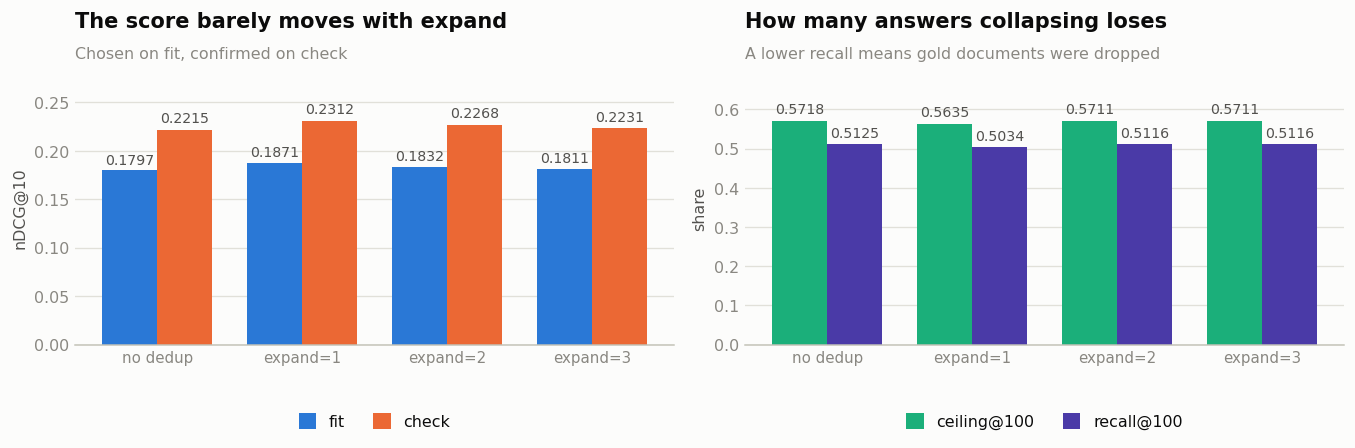

In [10]:
# --- The trade-off, drawn -------------------------------------------------
names = list(dedup_digests)
fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.0))

ax = axes[0]
xs = np.arange(len(names))
width = 0.38
fit_values = [dedup_summary[n]["fit"]["ndcg"] for n in names]
check_values = [dedup_summary[n]["check"]["ndcg"] for n in names]
b1 = ax.bar(xs - width / 2, fit_values, width, color=BLUE, label="fit")
b2 = ax.bar(xs + width / 2, check_values, width, color=ORANGE, label="check")
label_bars(ax, b1, fit_values, fmt="{:.4f}", horizontal=False, pad=0.02)
label_bars(ax, b2, check_values, fmt="{:.4f}", horizontal=False, pad=0.02)
ax.set_xticks(xs)
ax.set_xticklabels(names, fontsize=9)
ax.set_ylim(0, max(fit_values + check_values) * 1.22)
legend_below(ax, ncol=2, y=-0.20)
finish(ax, "The score barely moves with expand",
       subtitle="Chosen on fit, confirmed on check", ylabel="nDCG@10")

ax = axes[1]
ceilings = [dedup_summary[n]["macro"]["ceiling"] for n in names]
recalls = [dedup_summary[n]["macro"]["recall"] for n in names]
b1 = ax.bar(xs - width / 2, ceilings, width, color=TEAL, label="ceiling@100")
b2 = ax.bar(xs + width / 2, recalls, width, color=VIOLET, label="recall@100")
label_bars(ax, b1, ceilings, fmt="{:.4f}", horizontal=False, pad=0.02)
label_bars(ax, b2, recalls, fmt="{:.4f}", horizontal=False, pad=0.02)
ax.set_xticks(xs)
ax.set_xticklabels(names, fontsize=9)
ax.set_ylim(0, max(ceilings + recalls) * 1.22)
legend_below(ax, ncol=2, y=-0.20)
finish(ax, "How many answers collapsing loses",
       subtitle="A lower recall means gold documents were dropped",
       ylabel="share")

fig.tight_layout()
plt.show()

### Cách đọc hai biểu đồ

Biểu đồ trái là điểm hiện tại. Biểu đồ phải quan trọng hơn cho bước sau: nếu
`recall@100` tụt khi gộp, đó chính là đáp án bị bỏ mất — đúng cái bẫy đã nói
ở đầu notebook.

Quy tắc chọn: lấy `expand` nhỏ nhất mà **không làm tụt `recall`** so với lúc
không gộp. `expand` nhỏ thì mỗi chỗ trong danh sách là một nội dung khác nhau,
tức là bước xếp hạng lại có nhiều thứ để làm việc hơn.

In [11]:
# --- The rule, applied ----------------------------------------------------
baseline_recall = dedup_summary["no dedup"]["macro"]["recall"]
TOLERANCE = 0.002        # anything smaller is bootstrap noise, not a loss

safe = [name for name in names
        if name != "no dedup"
        and dedup_summary[name]["macro"]["recall"] >= baseline_recall - TOLERANCE]

print(f"recall without dedup: {baseline_recall:.4f}")
print(f"tolerance:            {TOLERANCE}")
print()
for name in names:
    if name == "no dedup":
        continue
    recall = dedup_summary[name]["macro"]["recall"]
    verdict = "safe" if name in safe else f"LOSES {baseline_recall - recall:.4f}"
    print(f"  {name:<12}recall {recall:.4f}   {verdict}")

if safe:
    CHOSEN_EXPAND = min(int(n.split("=")[1]) for n in safe)
    print(f"\nChosen: expand = {CHOSEN_EXPAND}, the smallest setting that "
          f"keeps every answer.")
else:
    CHOSEN_EXPAND = max(EXPANDS)
    print(f"\nEvery setting loses answers. Falling back to expand = "
          f"{CHOSEN_EXPAND}, which loses the fewest.")
    print("Worth reading the qrels for a few of the lost queries before "
          "trusting dedup in the final system.")

recall without dedup: 0.5125
tolerance:            0.002

  expand=1    recall 0.5034   LOSES 0.0090
  expand=2    recall 0.5116   safe
  expand=3    recall 0.5116   safe

Chosen: expand = 2, the smallest setting that keeps every answer.


---

## 5. Độ sâu cần lấy ở `07b`

Mục 2 đo được rằng một phần danh sách ứng viên là bản sao. Muốn đưa cho bộ xếp
hạng lại **1000 nội dung khác nhau**, tầng một phải lấy về sâu hơn 1000.

Mục này tính ra con số đó cho từng nhóm, dựa trên tỷ lệ gộp đo được.

In [12]:
# --- How deep must the first stage go ------------------------------------
TARGET_DISTINCT = 1000

print(f"To hand the reranker {TARGET_DISTINCT:,} distinct texts:")
print(f"\n{'domain':<12}{'kept share':>12}{'depth needed':>14}")
print("-" * 38)
needed = {}
for domain, n_queries, total, kept, share, _ in sorted(waste,
                                                       key=lambda w: -w[4]):
    ratio = kept / total                       # distinct per candidate
    depth = int(np.ceil(TARGET_DISTINCT / ratio))
    needed[domain] = depth
    print(f"{domain:<12}{ratio:>12.1%}{depth:>14,}")
print("-" * 38)

worst = max(needed.values())
print(f"{'worst case':<12}{'':>12}{worst:>14,}")
print()
print(f"Retrieving at depth {worst:,} everywhere costs the same as "
      f"{TARGET_DISTINCT:,}:")
print("the scoring is identical and only the size of the cut changes. The")
print("expensive part of a sparse run is building the index, which happens")
print("once regardless of the depth asked for.")
print()
print(f"07b therefore retrieves at depth {worst:,} and lets the dedup stage")
print(f"bring each list back down to roughly {TARGET_DISTINCT:,} distinct texts.")

RERANK_DEPTH = int(worst)

To hand the reranker 1,000 distinct texts:

domain        kept share  depth needed
--------------------------------------
bitcoin            49.0%         2,043
monero             63.7%         1,572
history            70.2%         1,425
cardano            73.7%         1,357
genealogy          79.7%         1,256
hsm                79.9%         1,252
travel             80.0%         1,251
workplace          80.0%         1,250
politics           81.3%         1,231
economics          84.2%         1,188
quant              88.6%         1,129
law                91.9%         1,089
iota               92.1%         1,086
--------------------------------------
worst case                       2,043

Retrieving at depth 2,043 everywhere costs the same as 1,000:
the scoring is identical and only the size of the cut changes. The
expensive part of a sparse run is building the index, which happens
once regardless of the depth asked for.

07b therefore retrieves at depth 2,043 and lets the de

---

## 6. Chốt cấu hình cho `07b`

Ghi ra file hệ thống mà `07b` sẽ dùng làm tầng một, và lưu lại các con số để
notebook sau đọc.

In [13]:
# --- The first stage 07b will use ----------------------------------------
FIRST_STAGE = {
    "name": "stage1_deep",
    "note": f"first stage for 07b: depth {RERANK_DEPTH}, dedup to distinct "
            f"texts, expand={CHOSEN_EXPAND}",
    "retrieve": dict(base_system["retrieve"], depth=RERANK_DEPTH),
    "dedup": {"kind": "content_hash", "expand": CHOSEN_EXPAND},
}
first_stage_path = SYSTEMS / "03_stage1_deep.json"
first_stage_path.write_text(json.dumps(FIRST_STAGE, indent=2),
                            encoding="utf-8")
print(f"wrote {first_stage_path}")
print(json.dumps(FIRST_STAGE, indent=1))

dedup_verdict = {
    "corpus_documents": total_docs,
    "corpus_distinct": distinct,
    "corpus_duplicate_share": 1 - distinct / total_docs,
    "candidate_waste_share": overall,
    "per_domain_waste": {w[0]: w[4] for w in waste},
    "gold_with_twin": sum(w[5] for w in waste),
    "expand_measured": {name: {
        "fit": dedup_summary[name]["fit"]["ndcg"],
        "check": dedup_summary[name]["check"]["ndcg"],
        "ndcg": dedup_summary[name]["macro"]["ndcg"],
        "recall": dedup_summary[name]["macro"]["recall"],
        "ceiling": dedup_summary[name]["macro"]["ceiling"],
    } for name in names},
    "chosen_expand": CHOSEN_EXPAND,
    "rerank_depth": RERANK_DEPTH,
    "target_distinct": TARGET_DISTINCT,
    "significance": dedup_significance,
}
(CACHE / "dedup_summary.json").write_text(
    json.dumps(dedup_verdict, indent=1), encoding="utf-8")
print(f"\nSaved {CACHE / 'dedup_summary.json'}")

wrote ..\systems\03_stage1_deep.json
{
 "name": "stage1_deep",
 "note": "first stage for 07b: depth 2043, dedup to distinct texts, expand=2",
 "retrieve": {
  "kind": "sparse",
  "query_form": "title_weighted",
  "tokenizer": "nohtml_stop",
  "model": "bm25",
  "k1": 2.0,
  "b": 0.9,
  "depth": 2043
 },
 "dedup": {
  "kind": "content_hash",
  "expand": 2
 }
}

Saved results\dedup_summary.json


In [14]:
# --- Every system measured so far ----------------------------------------
P.table()
print()
P.metrics()

name                          hash                fit    check   ceiling   topics
---------------------------------------------------------------------------------
bm25_tuned_dedup_e1           81353d99b661     0.1871   0.2312    0.5635     1211
bm25_tuned_dedup_e2           9bfc734c9e7c     0.1832   0.2268    0.5711     1211
bm25_tuned_dedup_e3           c4c9b2577b4a     0.1811   0.2231    0.5711     1211
bm25_tuned                    f326339da67a     0.1797   0.2215    0.5718     1211
bm25_default                  af3eb864b4b2     0.1434   0.1598    0.4584     1211
---------------------------------------------------------------------------------
Sorted by fit. `check` is read only after a choice is made, never sorted on.

name                                P@10      R@10     F1@10       MAP   nDCG@10     R@100
------------------------------------------------------------------------------------------
bm25_tuned_dedup_e1               0.0672    0.2509    0.1015    0.1515    0.1944    

[{'hash': '81353d99b661',
  'split': 'train',
  'score_version': 2,
  'name': 'bm25_tuned_dedup_e1',
  'macro': {'ndcg': 0.19442172523128984,
   'recall': 0.5034182563062898,
   'ceiling': 0.563510974980763,
   'precision': 0.06720387474770578,
   'f1': 0.10150294585079513,
   'recall_at_cut': 0.2508565210755412,
   'map': 0.15152187679329995},
  'n_topics': 1211,
  'n_gold_queries': 1211,
  'per_domain': {'bitcoin': {'ndcg': 0.14188718560755442,
    'recall': 0.33499999999999996,
    'precision': 0.04571428571428572,
    'f1': 0.06902890760033617,
    'recall_at_cut': 0.17488095238095233,
    'map': 0.1144723279511411,
    'ceiling': 0.38535461302560725,
    'n_topics': 70,
    'n_gold_queries': 70},
   'cardano': {'ndcg': 0.24561612416388254,
    'recall': 0.7164682539682539,
    'precision': 0.06666666666666668,
    'f1': 0.11072261072261072,
    'recall_at_cut': 0.3703703703703704,
    'map': 0.20141097112163175,
    'ceiling': 0.7556031360542671,
    'n_topics': 36,
    'n_gold_qu

---

## 7. Kết luận

### Điều notebook này cho thấy

| Điều | Số đo |
| --- | --- |
| Tỷ lệ bản sao trong kho | Mục 1 |
| Tỷ lệ chỗ bị bản sao chiếm trong danh sách ứng viên | Mục 2 |
| Số đáp án có bản sao cùng nằm trong danh sách | Mục 2, cột cuối |
| `expand` nên bằng bao nhiêu | Mục 4 |
| Độ sâu `07b` cần lấy | Mục 5 |

### Vì sao chọn `expand` theo `recall` chứ không theo `nDCG`

`nDCG@10` chỉ nhìn 10 dòng đầu. Một đáp án bị gộp nhầm mà vốn nằm ở hạng 40 thì
`nDCG@10` không thấy gì cả, nhưng bước xếp hạng lại ở `07b` lẽ ra đã kéo nó lên
được. Mất nó là mất luôn phần điểm đó, chỉ là mất ở bước sau.

`recall@100` nhìn cả danh sách, nên nó bắt được đúng loại mất mát này. Đó là lý
do quy tắc ở mục 4 đọc cột `recall`.

### Bước tiếp theo

Notebook `07b` lấy file `systems/03_stage1_deep.json` làm tầng một, xuất một
gói việc cho máy có GPU, và xếp hạng lại bằng cross-encoder.